# **Centrality Analyses**

In [1]:
import pandas as pd
import numpy as np
import networkx as nx

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
edges = pd.read_csv("../data/edges.csv")[["# source", " target", " distance"]].drop_duplicates()

nodes = pd.read_csv("../data/nodes.csv")[[" id", " name", " city", " country"]]
nodes[" id"] = np.arange(0, 3214)

In [3]:
source_airport = np.array(edges["# source"])
destination_airport = np.array(edges[" target"])

In [4]:
A = np.array([[0 for i in range(3214)] for i in range(3214)])

assert len(source_airport) == len(destination_airport)

for source, target, distance in edges.values:
    A[np.int16(source)][np.int16(target)] = distance


In [5]:
# nx representation (10 seconds)

G = nx.from_numpy_array(A) # Undirected!

In [26]:
def print_top_centrality(centrality_dict, nodes_df, top_n=10):
    id_to_name = dict(zip(nodes_df[" id"].astype(int), nodes_df[" name"]))
    centrality_list = [(int(n), float(s), id_to_name.get(int(n), "Unknown")) for n, s in centrality_dict.items()]
    centrality_list_sorted = sorted(centrality_list, key=lambda x: x[1], reverse=True)
    for i, (nid, score, name) in enumerate(centrality_list_sorted[:top_n], 1):
        print(f"{i}. {name} (id={nid}): {score:.6f}")

# **Distance centrality**

In [27]:
distance_centrality = nx.degree_centrality(G)
print_top_centrality(distance_centrality, nodes)

# sorted(distance_centrality.items(), key=lambda x: x[1], reverse=True)

# TOP 5 podľa "dôležitosti":

# Amsterdam Schipol
# Frankfurt Am Main
# Charles de Gaulle Paris
# Ataturk Intl Instanbul
# Hartsfield Atlanta

1. Amsterdam Airport Schiphol (id=282): 0.077186
2. Frankfurt am Main Airport (id=191): 0.075941
3. Charles de Gaulle International Airport (id=628): 0.074697
4. Atatürk International Airport (id=770): 0.072518
5. Hartsfield Jackson Atlanta International Airport (id=1809): 0.067538
6. Chicago O'Hare International Airport (id=1885): 0.064115
7. Beijing Capital International Airport (id=1642): 0.063803
8. Munich Airport (id=196): 0.059757
9. Dallas Fort Worth International Airport (id=1800): 0.058512
10. Domodedovo International Airport (id=2016): 0.058512


<Axes: ylabel='Density'>

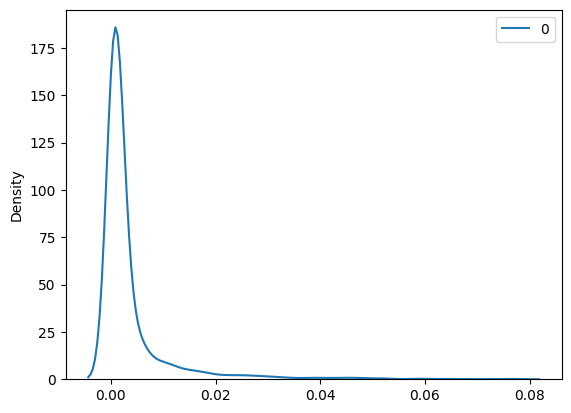

In [7]:
sns.kdeplot(distance_centrality.values())

# Betweenness Centrality

In [ ]:
betweenness_centrality = nx.betweenness_centrality(G)
print_top_centrality(betweenness_centrality, nodes)

1. Charles de Gaulle International Airport (id=628): 0.063563
2. Los Angeles International Airport (id=1715): 0.060503
3. Ted Stevens Anchorage International Airport (id=1861): 0.058427
4. Dubai International Airport (id=1017): 0.055406
5. Frankfurt am Main Airport (id=191): 0.052432
6. Amsterdam Airport Schiphol (id=282): 0.051063
7. Beijing Capital International Airport (id=1642): 0.049788
8. Chicago O'Hare International Airport (id=1885): 0.046583
9. Lester B. Pearson International Airport (id=125): 0.044345
10. Atatürk International Airport (id=770): 0.042428


<Axes: ylabel='Density'>

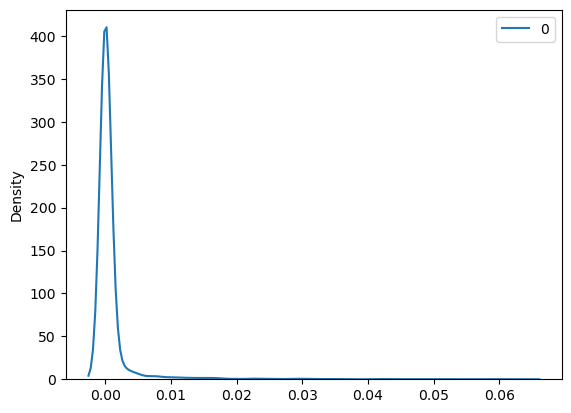

In [13]:
sns.kdeplot(betweenness_centrality.values())

# Eigenvector centrality

In [29]:
eigenvector_centrality = nx.eigenvector_centrality(G)
print_top_centrality(eigenvector_centrality, nodes)

1. Amsterdam Airport Schiphol (id=282): 0.167934
2. Frankfurt am Main Airport (id=191): 0.166436
3. Charles de Gaulle International Airport (id=628): 0.159498
4. Munich Airport (id=196): 0.148588
5. Leonardo da Vinci–Fiumicino Airport (id=706): 0.136380
6. London Heathrow Airport (id=255): 0.135963
7. Atatürk International Airport (id=770): 0.129197
8. Barcelona International Airport (id=570): 0.128204
9. Zürich Airport (id=758): 0.126053
10. Adolfo Suárez Madrid–Barajas Airport (id=578): 0.123032


<Axes: ylabel='Density'>

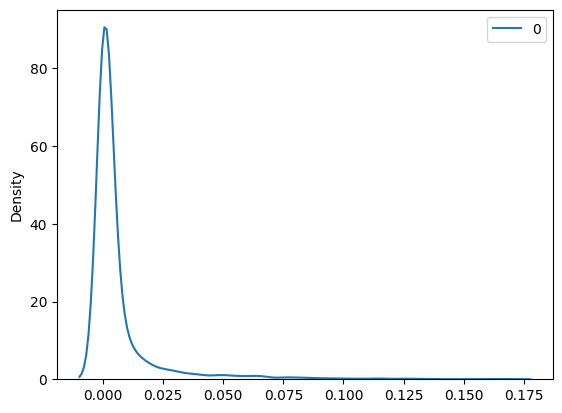

In [33]:
sns.kdeplot(eigenvector_centrality.values())

# Closeness centrality

In [30]:
closeness_centrality = nx.closeness_centrality(G)
print_top_centrality(closeness_centrality, nodes)

1. Frankfurt am Main Airport (id=191): 0.410920
2. Charles de Gaulle International Airport (id=628): 0.408320
3. London Heathrow Airport (id=255): 0.405752
4. Amsterdam Airport Schiphol (id=282): 0.401883
5. Dubai International Airport (id=1017): 0.400407
6. Los Angeles International Airport (id=1715): 0.394757
7. John F Kennedy International Airport (id=1870): 0.394264
8. Lester B. Pearson International Airport (id=125): 0.389600
9. Atatürk International Airport (id=770): 0.388451
10. Munich Airport (id=196): 0.387119


<Axes: ylabel='Density'>

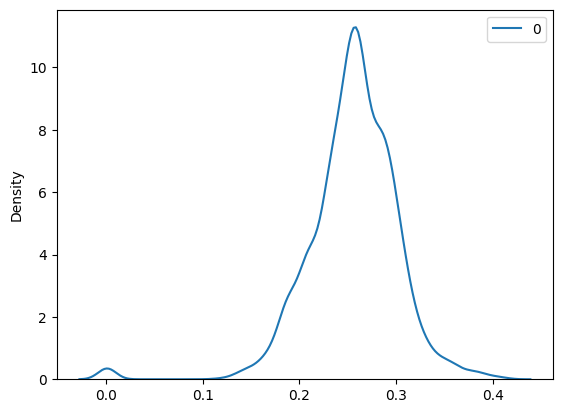

In [34]:
sns.kdeplot(closeness_centrality.values())

# Katz centrality

In [32]:
katz_centrality = nx.katz_centrality(G, alpha=0.005)
print_top_centrality(katz_centrality, nodes)

1. Amsterdam Airport Schiphol (id=282): 0.045923
2. Frankfurt am Main Airport (id=191): 0.045768
3. Charles de Gaulle International Airport (id=628): 0.045006
4. Atatürk International Airport (id=770): 0.042429
5. Munich Airport (id=196): 0.039947
6. Hartsfield Jackson Atlanta International Airport (id=1809): 0.039258
7. Beijing Capital International Airport (id=1642): 0.038985
8. Chicago O'Hare International Airport (id=1885): 0.038915
9. London Heathrow Airport (id=255): 0.038453
10. Dubai International Airport (id=1017): 0.037835


<Axes: ylabel='Density'>

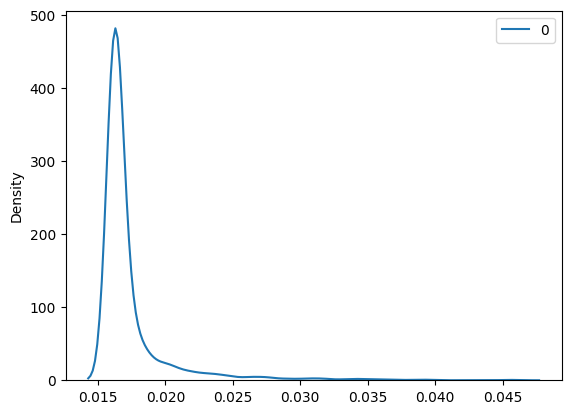

In [35]:
sns.kdeplot(katz_centrality.values())